In [ ]:
#Installing packages
!pip install scikit-learn pandas numpy matplotlib seaborn -q

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_raw = pd.read_csv('cardio_train.csv', sep=';') #Loading Dataset

#Exploring features
print(f'Shape: {df_raw.shape}')
print(f'Columns: {list(df_raw.columns)}')
df_raw.head()

Shape: (70000, 13)
Columns: ['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [4]:
print(df_raw.dtypes)
print()
print(df_raw.isnull().sum())
print()
df_raw.describe()

id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64



,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


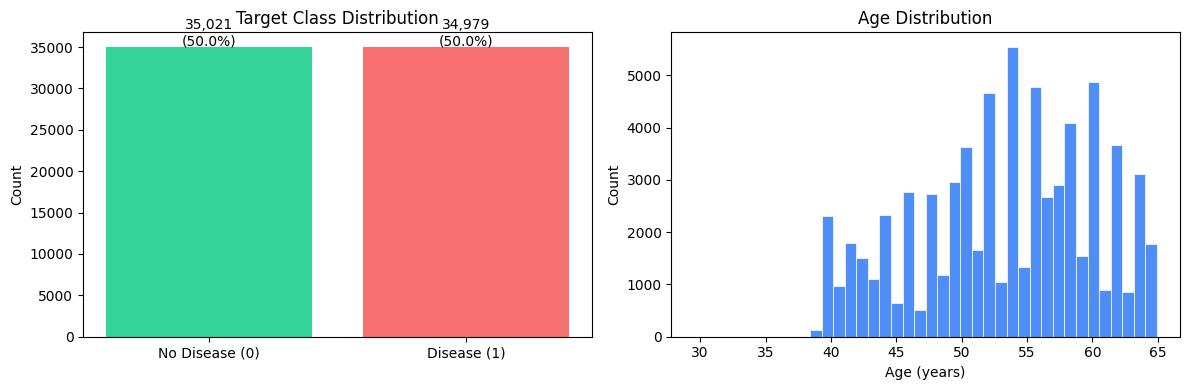

In [5]:
#Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

#Target class distribution (Disease vs No Disease)
counts = df_raw['cardio'].value_counts()
axes[0].bar(['No Disease (0)', 'Disease (1)'], counts.values, color=['#34D399', '#F87171'])
axes[0].set_title('Target Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}\n({v/len(df_raw)*100:.1f}%)', ha='center')

#Age distribution
axes[1].hist(df_raw['age'] / 365.25, bins=40, color='#4F8EF7', edgecolor='white', linewidth=0.5)
axes[1].set_title('Age Distribution')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [6]:
#Data cleaning
df = df_raw.copy()

#Droping id and active (Physical Activity) columns (Activity is useless for this project)
df = df.drop(columns=[c for c in ['id', 'active'] if c in df.columns])
print(f'After dropping id/active: {df.shape}')

#Removing unrealistic BP values
before = len(df)
df = df[df['ap_hi'].between(60, 280)]
df = df[df['ap_lo'].between(40, 180)]
df = df[df['ap_hi'] > df['ap_lo']]   #systolic > diastolic
print(f'After BP filter: {len(df)} rows (removed {before - len(df)})')

#Removing impossible height/weight values
before = len(df)
df = df[df['height'].between(100, 250)]
df = df[df['weight'].between(20, 250)]
print(f'After height/weight filter: {len(df)} rows (removed {before - len(df)})')

#Printing Final outcomes
print(f'\nFinal dataset shape: {df.shape}')
print(f'Final Class distribution:\n{df["cardio"].value_counts()}')

After dropping id/active: (70000, 11)
After BP filter: 68671 rows (removed 1329)
After height/weight filter: 68644 rows (removed 27)

Final dataset shape: (68644, 11)
Final Class distribution:
cardio
0    34684
1    33960
Name: count, dtype: int64


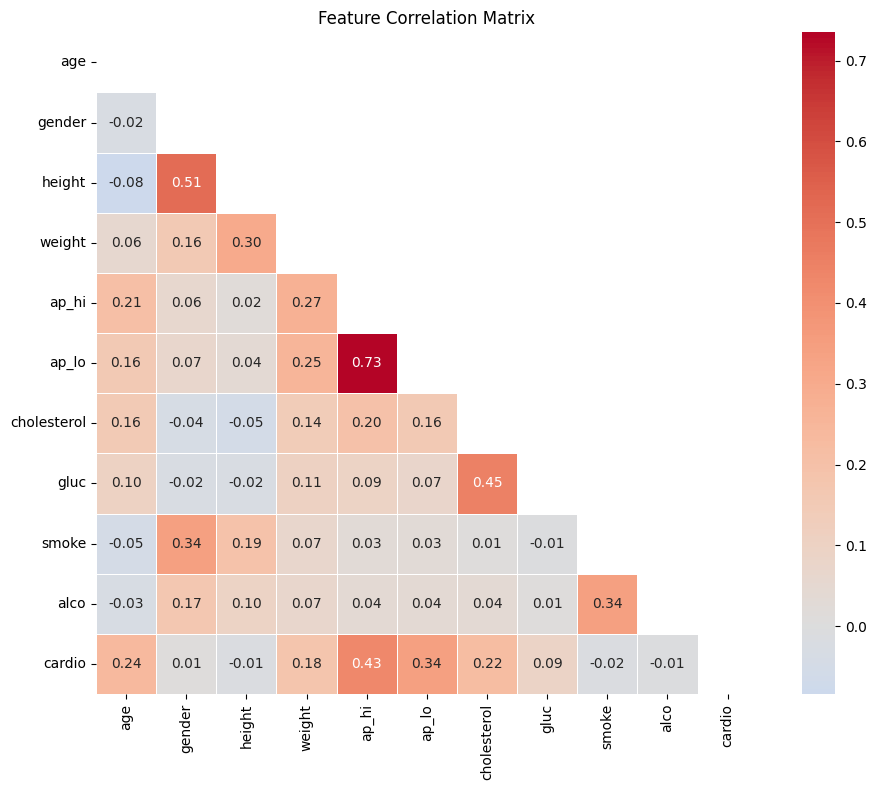

In [7]:
#Feature correlation heatmap
plt.figure(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [8]:
#Pre-processing and train-test split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pickle, os

FEATURE_COLUMNS = [
    'age', 'gender', 'height', 'weight',
    'ap_hi', 'ap_lo', 'cholesterol', 'gluc',
    'smoke', 'alco'
]
TARGET_COLUMN = 'cardio'
RANDOM_SEED = 42

X = df[FEATURE_COLUMNS].values
y = df[TARGET_COLUMN].values

#Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#80-20 split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

print(f'Training set:   {X_train.shape[0]:,} samples')
print(f'Test set:       {X_test.shape[0]:,} samples')
print(f'Features:       {X_train.shape[1]}')

#Creating Directory to save the data
os.makedirs('models', exist_ok=True)

#Saving scaler
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

Training set:   54,915 samples
Test set:       13,729 samples
Features:       10


In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, roc_auc_score, confusion_matrix,classification_report

all_metrics = {} #In this dictionary we''ll store metrices for each model after training

#Function to train model and saving it as {model}.pkl in models directory
#This Functions eliminates re-writting
def evaluate_and_save(name, model):

    print(f'Currently Training {name}...')
    model.fit(X_train, y_train) #Feeding Data
    y_pred = model.predict(X_test) #Testing
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        'accuracy':         round(accuracy_score(y_test, y_pred) * 100, 2),
        'precision':        round(precision_score(y_test, y_pred) * 100, 2),
        'recall':           round(recall_score(y_test, y_pred) * 100, 2),
        'f1':               round(f1_score(y_test, y_pred) * 100, 2),
        'roc_auc':          round(roc_auc_score(y_test, y_prob) * 100, 2),
        'confusion_matrix': confusion_matrix(y_test, y_pred).tolist(),
    }
    #Saving into models
    filename = name.replace(' ', '_').lower()
    with open(f'models/{filename}.pkl', 'wb') as f:
        pickle.dump(model, f)

    print(f'  Accuracy={metrics["accuracy"]}%  AUC={metrics["roc_auc"]}%  F1={metrics["f1"]}%')
    return metrics

In [10]:
#Training Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
#Using "evaluate_and_save" function and storing the information in all_metrices (here using model name as key)
all_metrics['Logistic Regression'] = evaluate_and_save('Logistic Regression', lr)

Currently Training Logistic Regression...
  Accuracy=72.22%  AUC=78.96%  F1=70.1%


In [11]:
#Similarly training and saving Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=150, max_depth=8, random_state=RANDOM_SEED, n_jobs=-1)
all_metrics['Random Forest'] = evaluate_and_save('Random Forest', rf)

Currently Training Random Forest...
  Accuracy=72.57%  AUC=79.77%  F1=70.34%


In [12]:
#Trainign KNN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=7, n_jobs=-1)
all_metrics['KNN'] = evaluate_and_save('KNN', knn)

Currently Training KNN...
  Accuracy=70.2%  AUC=75.67%  F1=69.28%


In [13]:
#Training SVM (training on 20k subset for speed because SVM is O(n^2) and it will take more than one hour to train on actual dataset)
from sklearn.svm import SVC

# Creating subset (20K rows)
subset_idx = np.random.RandomState(RANDOM_SEED).choice(len(X_train), 20000, replace=False)
X_svm = X_train[subset_idx]
y_svm = y_train[subset_idx]

svm = SVC(probability=True, kernel='rbf', C=1.0, random_state=RANDOM_SEED)
print('Training SVM on 20K rows')
svm.fit(X_svm, y_svm)

y_pred = svm.predict(X_test)
y_prob = svm.predict_proba(X_test)[:, 1]
all_metrics['SVM'] = {
    'accuracy':         round(accuracy_score(y_test, y_pred) * 100, 2),
    'precision':        round(precision_score(y_test, y_pred) * 100, 2),
    'recall':           round(recall_score(y_test, y_pred) * 100, 2),
    'f1':               round(f1_score(y_test, y_pred) * 100, 2),
    'roc_auc':          round(roc_auc_score(y_test, y_prob) * 100, 2),
    'confusion_matrix': confusion_matrix(y_test, y_pred).tolist(),
}
with open('models/svm.pkl', 'wb') as f:
    pickle.dump(svm, f)
m = all_metrics['SVM']
print(f'  Accuracy={m["accuracy"]}%  AUC={m["roc_auc"]}%  F1={m["f1"]}%')

Training SVM on 20K rows
  Accuracy=72.74%  AUC=78.74%  F1=70.85%


In [14]:
#Training Gradient Boosting classifier
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=4, random_state=RANDOM_SEED)
all_metrics['Gradient Boosting'] = evaluate_and_save('Gradient Boosting', gb)

Currently Training Gradient Boosting...
  Accuracy=72.84%  AUC=79.86%  F1=71.24%


In [15]:
#Training Naive Bayes classifier
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
all_metrics['Naive Bayes'] = evaluate_and_save('Naive Bayes', nb)

Currently Training Naive Bayes...
  Accuracy=70.77%  AUC=77.67%  F1=66.99%


In [16]:
#Training ANN
from sklearn.neural_network import MLPClassifier

ann = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    max_iter=300,
    random_state=RANDOM_SEED,
    early_stopping=True,
    validation_fraction=0.1,
    verbose=False
)
all_metrics['Neural Network'] = evaluate_and_save('Neural Network', ann)

Currently Training Neural Network...
  Accuracy=72.78%  AUC=79.79%  F1=71.48%


In [17]:
#Saving metrics.pkl (used by the Streamlit app for Analysis tab)
with open('models/metrics.pkl', 'wb') as f:
    pickle.dump(all_metrics, f)
print('Metrics saved -> models/metrics.pkl')

# Summary table
summary = pd.DataFrame({
    name: {
        'Accuracy (%)':  m['accuracy'],
        'Precision (%)': m['precision'],
        'Recall (%)':    m['recall'],
        'F1 (%)':        m['f1'],
        'ROC-AUC (%)':   m['roc_auc'],
    }
    for name, m in all_metrics.items()
}).T.sort_values('ROC-AUC (%)', ascending=False)

print('\n=== Model Performance Summary (sorted by AUC) ===')
summary

Metrics saved -> models/metrics.pkl

=== Model Performance Summary (sorted by AUC) ===


,Accuracy (%),Precision (%),Recall (%),F1 (%),ROC-AUC (%)
Gradient Boosting,72.84,74.80,68.01,71.24,79.86
Neural Network,72.78,74.20,68.95,71.48,79.79
Random Forest,72.57,75.62,65.75,70.34,79.77
Logistic Regression,72.22,74.97,65.81,70.10,78.96
SVM,72.74,75.23,66.95,70.85,78.74
Naive Bayes,70.77,75.90,59.95,66.99,77.67
KNN,70.20,70.70,67.92,69.28,75.67


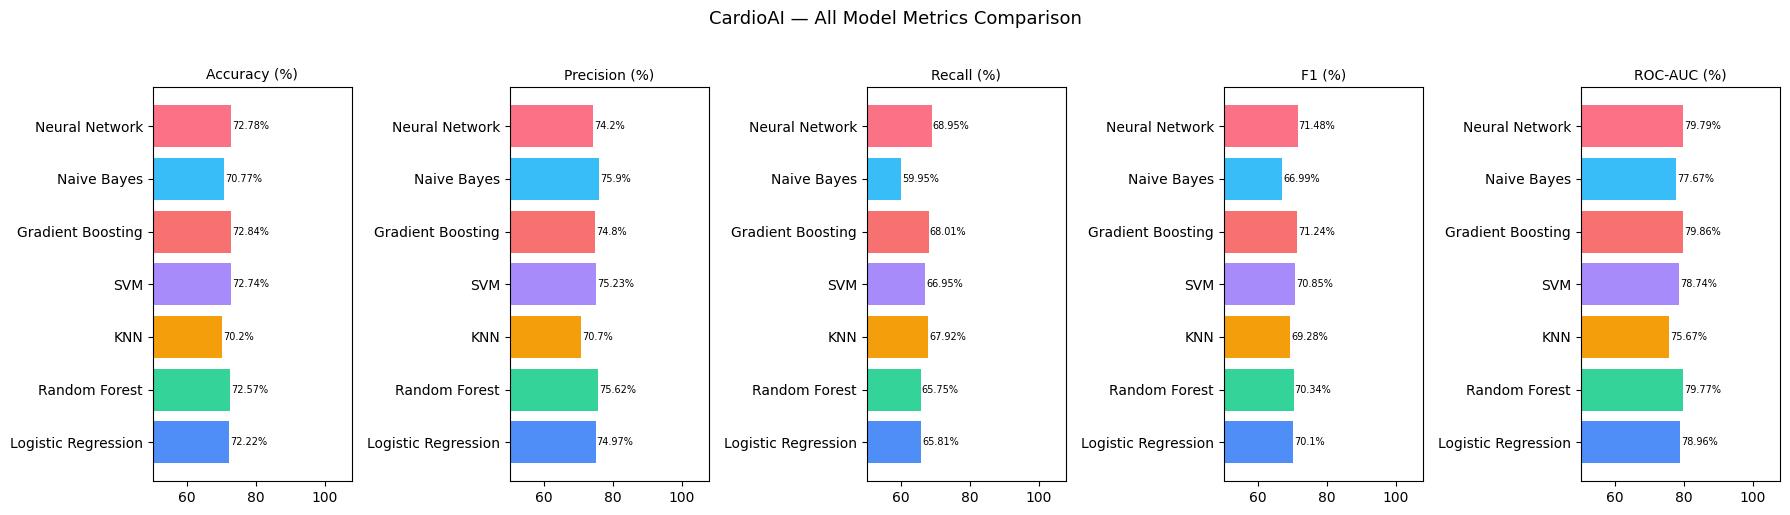

In [18]:
# Bar chart comparison
metrics_to_plot = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1 (%)', 'ROC-AUC (%)']
colors = ['#4F8EF7', '#34D399', '#F59E0B', '#A78BFA', '#F87171', '#38BDF8', '#FB7185']

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(18, 5))
model_names = list(all_metrics.keys())

for ax, metric in zip(axes, metrics_to_plot):
    vals = [all_metrics[n][metric.split(' ')[0].lower().replace('-', '_')] for n in model_names]
    bars = ax.barh(model_names, vals, color=colors[:len(model_names)], edgecolor='none')
    ax.set_xlim(50, 108)
    ax.set_title(metric, fontsize=10)
    for bar, v in zip(bars, vals):
        ax.text(v + 0.3, bar.get_y() + bar.get_height()/2,
                f'{v}%', va='center', fontsize=7)

plt.suptitle('CardioAI — All Model Metrics Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [19]:
import os

expected = [
    'scaler.pkl', 'metrics.pkl',
    'logistic_regression.pkl', 'random_forest.pkl', 'svm.pkl',
    'knn.pkl', 'gradient_boosting.pkl', 'naive_bayes.pkl', 'neural_network.pkl'
]

print('=== models/ folder contents ===')
all_ok = True
for fname in expected:
    path = f'models/{fname}'
    exists = os.path.exists(path)
    size_kb = round(os.path.getsize(path) / 1024, 1) if exists else 0
    status = f'OK   ({size_kb} KB)' if exists else 'MISSING'
    print(f'  {fname:<35} {status}')
    if not exists:
        all_ok = False

print()
if all_ok:
    print('All 9 files present. Ready to download.')
else:
    print('Some files are missing — re-run the relevant training cells.')

=== models/ folder contents ===
  scaler.pkl                          OK   (0.7 KB)
  metrics.pkl                         OK   (0.9 KB)
  logistic_regression.pkl             OK   (0.8 KB)
  random_forest.pkl                   OK   (4901.4 KB)
  svm.pkl                             OK   (1179.1 KB)
  knn.pkl                             OK   (5533.3 KB)
  gradient_boosting.pkl               OK   (351.0 KB)
  naive_bayes.pkl                     OK   (0.9 KB)
  neural_network.pkl                  OK   (283.9 KB)

All 9 files present. Ready to download.
